Data Collection → Data Cleaning → Descriptive Statistics → Data Transformation → Feature Engineering → Scaling

## Exploratory Data Analysis

### Data Collection

The employee dataset was synthetically generated using Python and the Faker library. 
It contains 50 employee records with employee ID, name, IT-related job position, 
start date, and salary.

The generated records were inserted into a PostgreSQL cloud database hosted on Neon. 
The employee records were retrieved using the SQL query `SELECT * FROM employees` 
through psycopg2 and loaded into a Pandas DataFrame for exploratory data analysis.

In [3]:
from src.load_employees import EmployeeDataLoader
import pandas as pd

loader = EmployeeDataLoader()

df = loader.load_data()

df.head()

,employee_id,name,position,start_date,salary,department_id
0,46,Michelle Smith,Software Developer,2019-01-05,67003,1
1,4,Douglas Davis,Backend Developer,2018-12-16,183733,1
2,25,Mary Ryan,Backend Developer,2022-12-15,199195,1
3,28,Bonnie Martin,Backend Developer,2022-08-28,165317,1
4,35,James Avery MD,Backend Developer,2023-06-07,185658,1


### Data Cleaning

The dataset was examined for missing values, duplicate records, incorrect data types, 
and values outside the expected ranges. Salary values were expected to be between 
$60,000 and $200,000, while employee start dates were expected to fall between 
2015 and 2024.

In [4]:
# Check the structure and data types
df.info()

# Check for missing values
df.isnull().sum()

# Check for duplicate records
df.duplicated().sum()

# Check salary range
print("Minimum salary:", df["salary"].min())
print("Maximum salary:", df["salary"].max())

# Check start date range
print("Earliest start date:", df["start_date"].min())
print("Latest start date:", df["start_date"].max())

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   employee_id    50 non-null     int64 
 1   name           50 non-null     str   
 2   position       50 non-null     str   
 3   start_date     50 non-null     object
 4   salary         50 non-null     int64 
 5   department_id  50 non-null     int64 
dtypes: int64(3), object(1), str(2)
memory usage: 2.5+ KB
Minimum salary: 60897
Maximum salary: 199608
Earliest start date: 2015-02-02
Latest start date: 2024-09-15


### Descriptive Statistics

Descriptive statistics are used to understand the numerical data. This shows information such as the average salary, minimum and maximum values, and other summary values.

In [5]:
df.describe()


,employee_id,salary,department_id
count,50.00000,50.000000,50.000000
mean,25.50000,139259.480000,2.260000
std,14.57738,40290.392478,1.352398
min,1.00000,60897.000000,1.000000
25%,13.25000,106058.500000,1.000000
50%,25.50000,147180.000000,2.000000
75%,37.75000,176783.000000,3.000000
max,50.00000,199608.000000,5.000000


### Data Transformation

The `start_date` column is converted into a Pandas datetime format. A new column called `start_year` is then created from the start date so employees can be analyzed based on the year they joined.

In [6]:

df["start_date"] = pd.to_datetime(df["start_date"])

df["start_year"] = df["start_date"].dt.year

df.head()

,employee_id,name,position,start_date,salary,department_id,start_year
0,46,Michelle Smith,Software Developer,2019-01-05,67003,1,2019
1,4,Douglas Davis,Backend Developer,2018-12-16,183733,1,2018
2,25,Mary Ryan,Backend Developer,2022-12-15,199195,1,2022
3,28,Bonnie Martin,Backend Developer,2022-08-28,165317,1,2022
4,35,James Avery MD,Backend Developer,2023-06-07,185658,1,2023


### Feature Engineering

A new column called `years_of_service` is created to show approximately how many years each employee has worked. It is calculated using the employee's start date and the end of 2024.

In [7]:
reference_date = pd.Timestamp("2024-12-31")

df["years_of_service"] = (
    (reference_date - df["start_date"]).dt.days / 365.25
).round(1)

df.head()

,employee_id,name,position,start_date,salary,department_id,start_year,years_of_service
0,46,Michelle Smith,Software Developer,2019-01-05,67003,1,2019,6.0
1,4,Douglas Davis,Backend Developer,2018-12-16,183733,1,2018,6.0
2,25,Mary Ryan,Backend Developer,2022-12-15,199195,1,2022,2.0
3,28,Bonnie Martin,Backend Developer,2022-08-28,165317,1,2022,2.3
4,35,James Avery MD,Backend Developer,2023-06-07,185658,1,2023,1.6


### Scaling

The salary values are converted to a range between 0 and 1 using Min-Max scaling. The original salary is kept, and the scaled value is stored in a new column called `salary_scaled`.

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["salary_scaled"] = scaler.fit_transform(df[["salary"]])

df.head()

,employee_id,name,position,start_date,salary,department_id,start_year,years_of_service,salary_scaled
0,46,Michelle Smith,Software Developer,2019-01-05,67003,1,2019,6.0,0.044020
1,4,Douglas Davis,Backend Developer,2018-12-16,183733,1,2018,6.0,0.885553
2,25,Mary Ryan,Backend Developer,2022-12-15,199195,1,2022,2.0,0.997023
3,28,Bonnie Martin,Backend Developer,2022-08-28,165317,1,2022,2.3,0.752788
4,35,James Avery MD,Backend Developer,2023-06-07,185658,1,2023,1.6,0.899431


## Visualization 1: Average Salary by Position and Start Year

The grouped bar chart below shows the average salary for each job position based on the year employees started. This helps compare salary differences across job positions and start years.

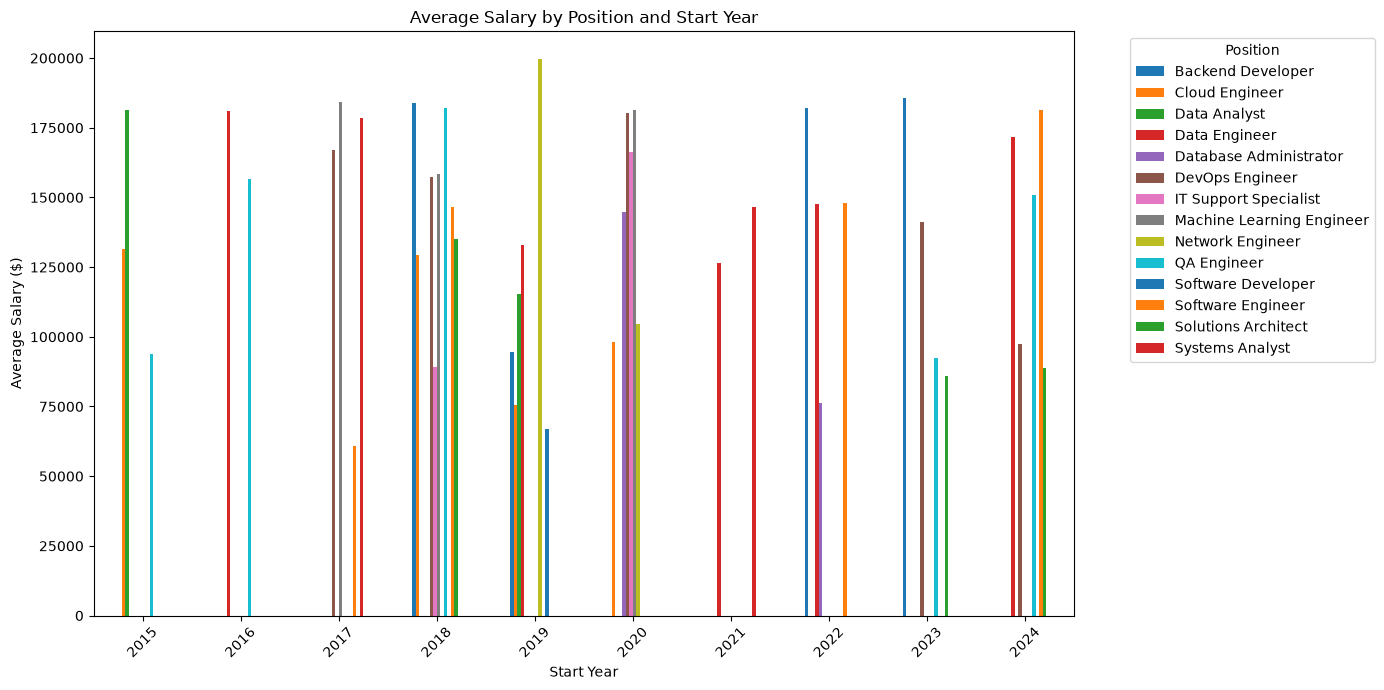

In [9]:
from src.visualization import EmployeeVisualizer

visualizer = EmployeeVisualizer(df)

visualizer.plot_average_salary_by_position_year()

## Visualization 2: Average Salary by Department and Position

For the advanced analysis, a second table containing department information was added to the PostgreSQL database. Employees were assigned to departments based on their job positions.

The `employees` and `departments` tables were combined using an SQL `JOIN` on the `department_id` column. The joined dataset contains employee information along with department name, location, and budget.

In [10]:
from src.departments import DepartmentDataManager

manager = DepartmentDataManager()

manager.populate_departments()
manager.assign_departments_to_employees()

department_df = manager.load_employee_department_data()

department_df.head()

Departments inserted successfully.
Departments assigned to employees successfully.


c:\Conestoga_Projects\Conestoga_Projects\Machine Learning Programing\Machine_Learning_Programing\src\departments.py:107: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,employee_id,name,position,start_date,salary,department_name,location,budget
0,46,Michelle Smith,Software Developer,2019-01-05,67003,Software Development,Toronto,1500000
1,4,Douglas Davis,Backend Developer,2018-12-16,183733,Software Development,Toronto,1500000
2,25,Mary Ryan,Backend Developer,2022-12-15,199195,Software Development,Toronto,1500000
3,28,Bonnie Martin,Backend Developer,2022-08-28,165317,Software Development,Toronto,1500000
4,35,James Avery MD,Backend Developer,2023-06-07,185658,Software Development,Toronto,1500000


### Heatmap

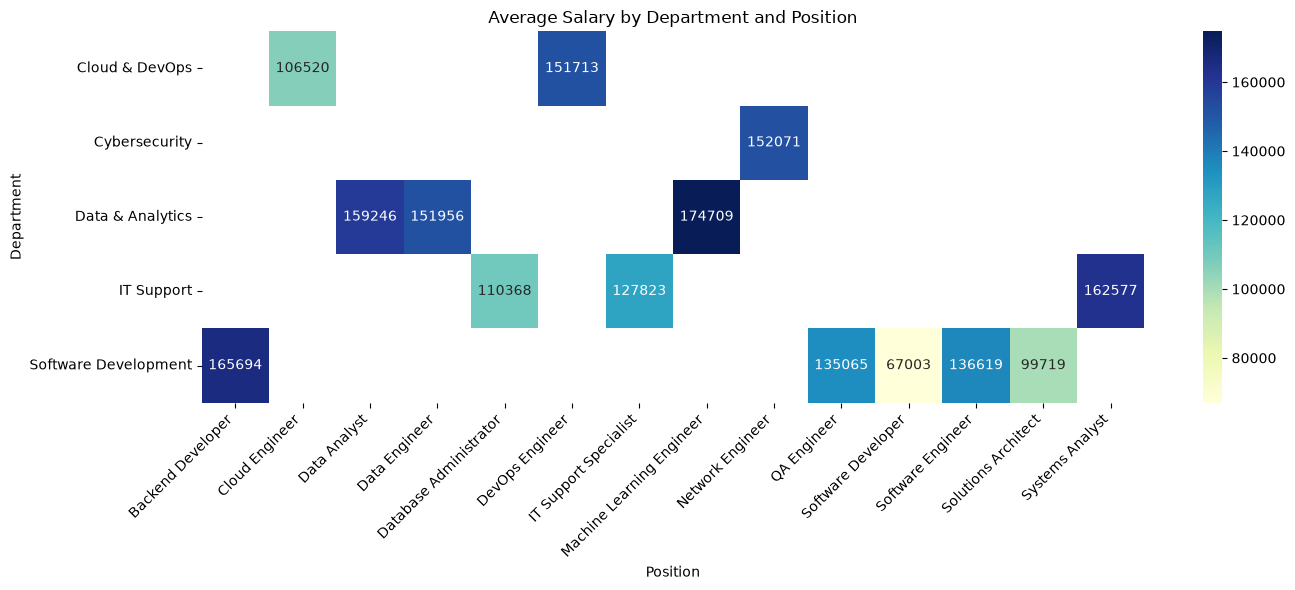

In [11]:
advanced_visualizer = EmployeeVisualizer(department_df)

advanced_visualizer.plot_salary_heatmap()

## Insights & Conclusions

The employee data was checked for missing values, duplicate records, correct data types, salary ranges, and start dates.

The grouped bar chart was used to compare the average salary of different job positions based on the year employees started.

For the advanced analysis, employee data was joined with department data. The heatmap was used to compare the average salaries of different job positions across departments.

New columns such as `start_year` and `years_of_service` were created for further analysis. Min-Max scaling was also used to convert salary values to a range between 0 and 1.

Overall, this project shows how data can be collected from a PostgreSQL cloud database, cleaned, transformed, analyzed, and visualized using Python.